# Lab 1: Introduction to Qiskit and Single-Qubit Gates

Welcome to your first lab on quantum computing with Qiskit! In this notebook, we will cover the absolute basics:
*   Setting up the environment.
*   Creating a simple quantum circuit.
*   Applying the fundamental Pauli gates (X, Y, and Z).
*   Simulating our circuits to see the results in three different ways:
    1.  **Statevector Simulation:** To see the pure quantum state.
    2.  **Unitary Simulation:** To see the mathematical matrix of our circuit.
    3.  **Measurement Simulation (`qasm_simulator`):** To see the probabilistic outcomes you'd get on a real quantum computer.

Let's get started!

### 1. Setup and Installation

First, we need to make sure the necessary Python libraries are installed. The following command uses `pip` to install `qiskit`, `qiskit-aer` (for simulations), and `matplotlib` (for plotting).

**Note:** You only need to run this cell once. If you have already installed these libraries, you can skip it.

In [ ]:
%pip install qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00


### 2. Importing Libraries and Checking Versions

Now, let's import all the tools we'll need from these libraries. It's good practice to do this at the beginning of any project. We will also print the Qiskit version to ensure our code is running in a compatible environment.

In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.visualization import plot_histogram
import matplotlib
from math import pi, sqrt # pi = 3.14 and square root operation
from qiskit.visualization import plot_bloch_multivector # Plotting the Bloch Sphere for Single Qubits
from qiskit.visualization import plot_histogram # 2D Histogram Plotting

In [ ]:
print(qiskit.__version__)

2.5.1


`qiskit-aer` provides several high-performance simulators. Let's see which ones are available on our system. We will primarily use the `statevector_simulator`, `unitary_simulator`, and `qasm_simulator`.

In [ ]:
Aer.backends()

[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

### 3. Building Your First Quantum Circuit

A quantum circuit is the primary model for quantum computation. We define our qubits, apply a sequence of quantum gates to them, and then typically measure them to get a classical result.

Here, we create one **Quantum Register** (`qr`) with a single qubit and one **Classical Register** (`cr`) with a single classical bit to store the measurement result.

In [ ]:
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit

In [ ]:
cr = ClassicalRegister(1,"cr")
qr = QuantumRegister(1,"qr")
qc = QuantumCircuit(qr,cr)


Let's see what our empty circuit looks like. As you can see, we have a quantum wire (`qr_0`) and a classical wire (`cr_0`), but no operations have been applied yet.

In [ ]:
pip install pylatexenc

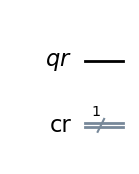

In [ ]:

qc.draw(output='mpl')

#### Basic Qiskit Information

- **All qubits in Qiskit starts from the state |0> by default**
- **Qiskit uses little endian ordering system for both classical bit and quantum bit ordering. This means that for 3 qubits $q_0$, $q_1$ & $q_2$, the qiskit ordering is reversed as $q_2$, $q_1$ & $q_0$. Same is for classical bits as well.**

---
***Pauli X Gate***

---

## The Pauli-X Gate (The Quantum NOT Gate)

The Pauli-X gate is the quantum equivalent of the classical NOT gate. It flips the state of a qubit.
*   If the qubit is in state $|0\rangle$, the X-gate transforms it to $|1\rangle$.
*   If the qubit is in state $|1\rangle$, the X-gate transforms it to $|0\rangle$.

On the Bloch Sphere, this corresponds to a 180-degree rotation around the X-axis.

### 3.1. Simulating the Statevector

Let's see the effect of the X-gate on a qubit that starts in the default state, $|0\rangle$. We will use the `statevector_simulator`, which calculates the exact quantum state of the circuit. A statevector is a mathematical vector that describes the qubit's state in the form $[\alpha, \beta]$, corresponding to $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$.

The initial state $|0\rangle$ is represented by the vector `[1, 0]`. Let's see what it becomes.

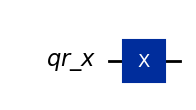

In [ ]:
# Pauli-X gate on |0> qubit
qr_x = QuantumRegister(1, 'qr_x')
cr_x = ClassicalRegister(1, 'cr_x')

qc_x = QuantumCircuit(qr_x)

# apply X-gate to the 0th qubit
qc_x.x(qr_x[0])
# qc.save_statevector()
# qc.save_unitary()
qc_x.draw(output='mpl')

***Bloch Sphere***

The output `[0.+0.j, 1.+0.j]` represents the state $0|0\rangle + 1|1\rangle$, which is exactly the state $|1\rangle$. The gate successfully flipped our qubit!

Let's visualize this on the Bloch Sphere. A qubit in state $|0\rangle$ points to the North Pole. A qubit in state $|1\rangle$ points to the South Pole. The plot clearly shows the state vector pointing downwards to the $|1\rangle$ position.

Result after implementing x-gate: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


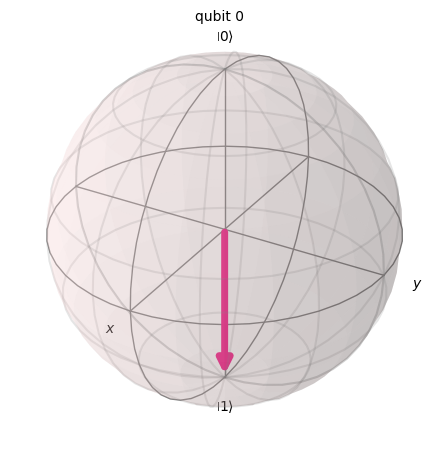

In [ ]:
backend = Aer.get_backend('statevector_simulator')
transpiled_qc_x = transpile(qc_x, backend)
result = backend.run(transpiled_qc_x).result().get_statevector(qc_x, decimals=3)


print("Result after implementing x-gate:",result)

plot_bloch_multivector(result)

***Unitary Gate***

### 3.2. Simulating the Unitary Matrix

Every quantum operation, including an entire circuit, can be represented by a unitary matrix. The `unitary_simulator` calculates this matrix for us. For a circuit with just a single X-gate, the result should be the Pauli-X matrix itself: $X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$.

The output matches the theoretical matrix for the Pauli-X gate, as expected.

In [ ]:
backend = Aer.get_backend('unitary_simulator')
result = backend.run(transpiled_qc_x).result().get_unitary(qc_x, decimals=3)
print("Unitary matrix after implementing x-gate:\n",result)

Unitary matrix after implementing x-gate:
 Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


***Measurement after Pauli-X Gate***

### 3.3. Simulating Measurement

The `statevector_simulator` gives us a "God's-eye view" of the quantum state. However, in a real quantum computer, we can't see the statevector. We must **measure** the qubit, which collapses its state to a definite `0` or `1`.

The `qasm_simulator` mimics this process. It runs the circuit multiple times (called "shots") and counts the frequency of each outcome.

Since our state after the X-gate is $|1\rangle$, we expect to measure the outcome `1` with 100% probability.

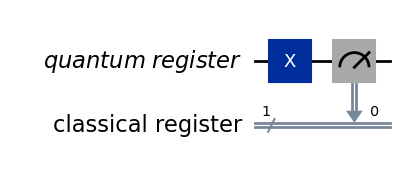

In [ ]:
# measurening the qubit |0> after applying X-gate

cr_x = ClassicalRegister(1, 'classical register')
qr_x = QuantumRegister(1, 'quantum register')
qc_x = QuantumCircuit(qr_x, cr_x)

qc_x.x(qr_x[0])

qc_x.measure(qr_x, cr_x)    # measure the qubit

qc_x.draw(output='mpl')

***Pauli-X Gate on QASM simulator***

The result `{'1': 1024}` (or similar, depending on the number of shots) means that the circuit was run 1024 times, and every single time the measurement resulted in the classical bit `1`. This is exactly what we predicted. We can visualize these counts with a histogram.

Counts after applying X-gate and measuring the qubit: {'1': 1024}


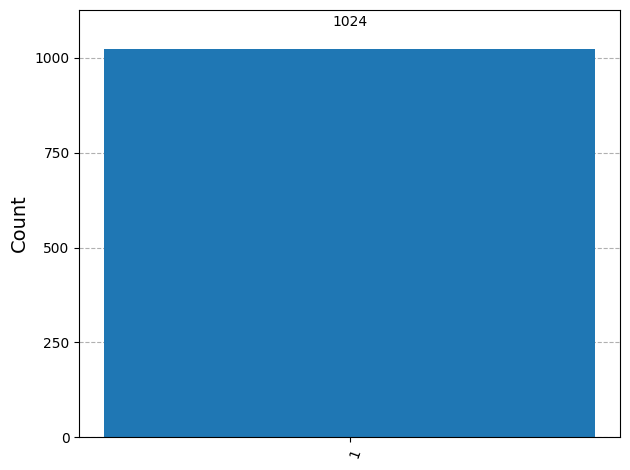

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_x, backend)

result = backend.run(job).result()
counts = result.get_counts(qc_x)

print("Counts after applying X-gate and measuring the qubit:",counts)

plot_histogram(counts)

***Multiple Qubits***

### 3.4. A Note on Measuring Multi-Qubit Circuits

Qiskit provides convenient ways to measure multiple qubits. Let's look at a 2-qubit circuit where we apply an X-gate to the first qubit (q0) and leave the second qubit (q1) in its initial $|0\rangle$ state. The total state is $|1\rangle \otimes |0\rangle = |10\rangle$.

**Important Note on Qiskit's Bit Ordering:** Qiskit orders bits from right to left. So, the state $|q_1 q_0\rangle$ will be represented by the classical string `'c1c0'`. For our state $|10\rangle$, we expect to measure the string `'10'`.

You can measure qubits individually. A `barrier` is a directive that prevents gate reordering during compilation and also makes the circuit diagram easier to read.

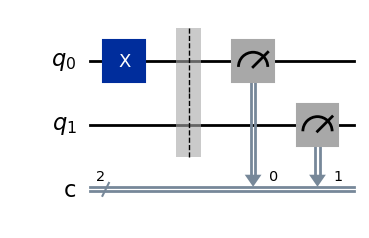

In [ ]:
qc_x = QuantumCircuit(2,2,name='qc_x')
# apply X-gate to the 0th qubit
qc_x.x(0)
# applying barrier
qc_x.barrier()
# qc_x.measure(0,0)
# qc_x.measure(1,1)
# [0,1] is the list of qubits to be measured
# [0,1] is the list of clbits to store the result
qc_x.measure([0,1],[0,1])

qc_x.draw(output='mpl')


Alternatively, you can use the `measure_all()` helper function. This automatically adds a classical register and measures each qubit into its corresponding classical bit.

If you were to run either of these circuits on the `qasm_simulator`, you would get the result `{'10': 1024}` because qubit 1 is in state $|0\rangle$ and qubit 0 is in state $|1\rangle$.

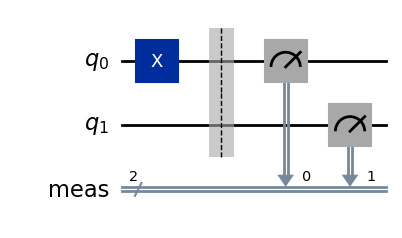

In [ ]:
qc_x = QuantumCircuit(2,name='qc_x')
# apply X-gate to the 0th qubit
qc_x.x(0)

# measuring all qubits
qc_x.measure_all()

qc_x.draw(output='mpl')

***Multiple Qubits***

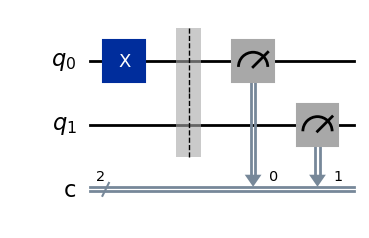

In [ ]:
qc_x = QuantumCircuit(2,2,name='qc_x')
# apply X-gate to the 0th qubit
qc_x.x(0)
# applying barrier
qc_x.barrier()
# qc_x.measure(0,0)
# qc_x.measure(1,1)
# [0,1] is the list of qubits to be measured
# [0,1] is the list of clbits to store the result
qc_x.measure([0,1],[0,1])

qc_x.draw(output='mpl')


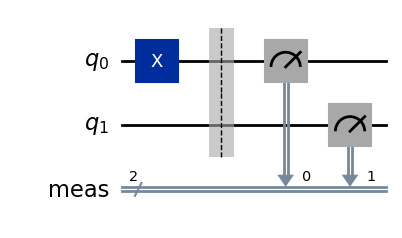

In [ ]:
qc_x = QuantumCircuit(2,name='qc_x')
# apply X-gate to the 0th qubit
qc_x.x(0)

# measuring all qubits
qc_x.measure_all()

qc_x.draw(output='mpl')

---
***Pauli Y Gate***

---

## The Pauli-Y Gate

The Pauli-Y gate is another fundamental single-qubit gate. It performs a 180-degree rotation around the Y-axis of the Bloch Sphere.

*   It maps $|0\rangle \rightarrow i|1\rangle$
*   It maps $|1\rangle \rightarrow -i|0\rangle$

Its matrix form is $Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$.

### 4.1. Statevector and Unitary Simulation

Let's apply the Y-gate to a $|0\rangle$ qubit and check the resulting statevector and unitary matrix.

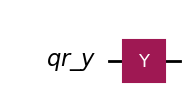

In [ ]:
# Pauli-Y gate on |0> qubit
qr_y = QuantumRegister(1, 'qr_y')
cr_y = ClassicalRegister(1, 'cr_y')

qc_y = QuantumCircuit(qr_y)

# apply Y-gate to the 0th qubit
qc_y.y(qr_y[0])
# qc.save_statevector()
# qc.save_unitary()
qc_y.draw(output='mpl')

***Bloch Sphere***

The statevector is `[0.+0.j, 0.+1.j]`, which corresponds to $0|0\rangle + i|1\rangle$, or $i|1\rangle$. This is exactly the expected result. The unitary matrix also matches the definition of the Y-gate.

Let's look at the Bloch Sphere. The vector still points to the south pole, indicating it will be measured as $|1\rangle$. The complex phase `i` is a global phase in this case and is not visible on the Bloch Sphere.

Result after implementing y-gate:
 Statevector([0.-0.j, 0.+1.j],
            dims=(2,))


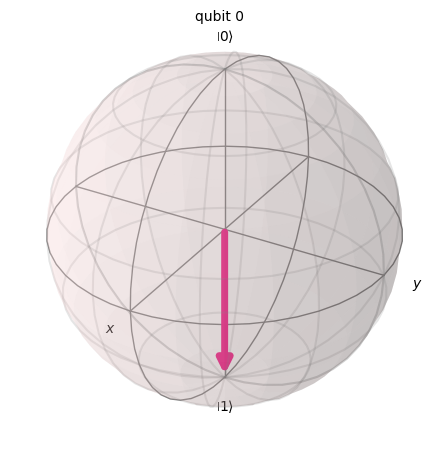

In [ ]:
backend = Aer.get_backend('statevector_simulator')
transpiled_qc_y = transpile(qc_y, backend)
result = backend.run(transpiled_qc_y).result().get_statevector(qc_y, decimals=3)


print("Result after implementing y-gate:\n",result)

plot_bloch_multivector(result)

***Unitary Gate***

In [ ]:
backend = Aer.get_backend('unitary_simulator')
result = backend.run(transpiled_qc_y).result().get_unitary(qc_y, decimals=3)
print("Unitary matrix after implementing y-gate:\n",result)

Unitary matrix after implementing y-gate:
 Operator([[0.-0.j, 0.-1.j],
          [0.+1.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


***Measurement after Pauli-Y Gate***

### 4.2. Simulating Measurement

What happens when we measure the state $i|1\rangle$? The probability of measuring `1` is given by the square of the magnitude of its amplitude. In this case, the probability is $|i|^2 = 1$. So, just like the X-gate, we expect to measure `1` with 100% probability. The phase `i` does not affect the measurement outcome in the standard (Z) basis.

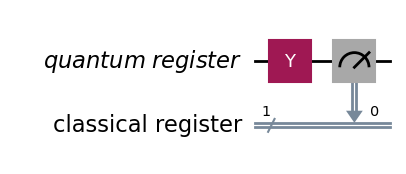

In [ ]:
# Measuring the qubit |0> after applying Y-gate
qr_y = QuantumRegister(1, 'quantum register')
cr_y = ClassicalRegister(1, 'classical register')
qc_y = QuantumCircuit(qr_y, cr_y)

qc_y.y(qr_y[0])

qc_y.measure(qr_y, cr_y)    # measure the qubit

qc_y.draw(output='mpl')


***Pauli-Y Gate on QASM simulator***

As predicted, we only ever measure `1`.

Counts after applying Y-gate and measuring the qubit: {'1': 1024}


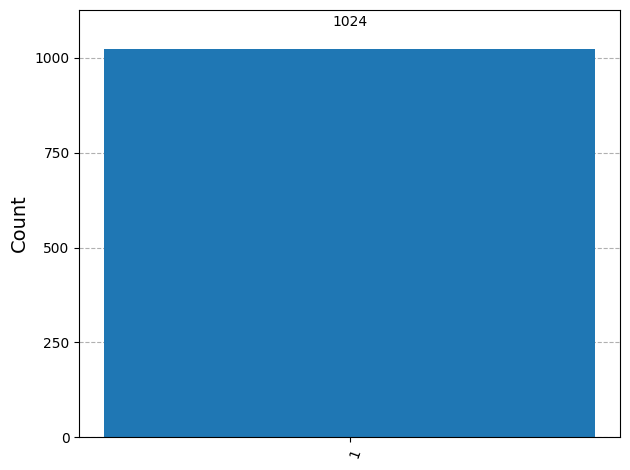

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_y, backend)

result = backend.run(job).result()
counts = result.get_counts(qc_y)

print("Counts after applying Y-gate and measuring the qubit:",counts)

plot_histogram(counts)

***Multiple Qubits***

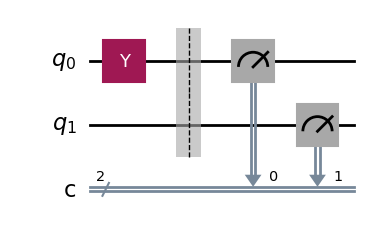

In [ ]:
qc_y = QuantumCircuit(2,2,name='qc_y')
# apply Y-gate to the 0th qubit
qc_y.y(0)
# applying barrier
qc_y.barrier()
# qc_y.measure(0,0)
# qc_y.measure(1,1)
# [0,1] is the list of qubits to be measured
# [0,1] is the list of clbits to store the result
qc_y.measure([0,1],[0,1])

qc_y.draw(output='mpl')


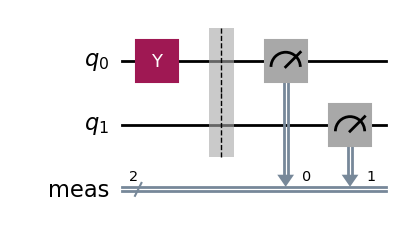

In [ ]:
qc_y = QuantumCircuit(2,name='qc_y')
# apply Y-gate to the 0th qubit
qc_y.y(0)

# measuring all qubits
qc_y.measure_all()

qc_y.draw(output='mpl')

---
***Pauli-Z Gate***

---

## The Pauli-Z Gate

The Pauli-Z gate is a "phase flip" gate. It performs a 180-degree rotation around the Z-axis of the Bloch Sphere.
*   It leaves the $|0\rangle$ state unchanged: $|0\rangle \rightarrow |0\rangle$.
*   It adds a negative phase to the $|1\rangle$ state: $|1\rangle \rightarrow -|1\rangle$.

Its matrix form is $Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$.

Applying a Z-gate to a $|0\rangle$ qubit does nothing interesting. To see its effect, let's first put the qubit into the $|1\rangle$ state using an X-gate, and *then* apply the Z-gate. The sequence of operations should be:
$|0\rangle \xrightarrow{X} |1\rangle \xrightarrow{Z} -|1\rangle$.

### 5.1. Statevector Simulation

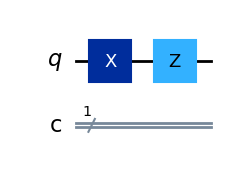

In [ ]:
# Pauli-Y gate on |0> qubit
qc_z = QuantumCircuit(1,1,name='qc_z')

# apply x-gate to the 0th qubit
qc_z.x(0)
# apply z-gate to the 0th qubit
qc_z.z(0)
# qc.save_statevector()
# qc.save_unitary()
qc_z.draw(output='mpl')

***Bloch Sphere***

The resulting statevector is `[0.+0.j, -1.+0.j]`, which corresponds to the state $-1|1\rangle$ or $-|1\rangle$. This is exactly what we expected!

Notice the Bloch Sphere visualization. The vector is at the South Pole, just as it was for the pure $|1\rangle$ state. A global phase or a phase applied to a state on the Z-axis (like $|1\rangle \rightarrow -|1\rangle$) is not visible on the Bloch sphere.

### 5.2. Measurement
Just like with the Y-gate, this phase change does not affect the measurement outcome. The probability of measuring `1` from the state $-|1\rangle$ is $|-1|^2 = 1$. If you were to add a measurement and run this on the `qasm_simulator`, the outcome would be `1` with 100% probability. This demonstrates a key concept: **phases matter for quantum interference, but certain phases are unobservable in a direct measurement.**

Result after implementing z-gate:
 Statevector([ 0.+0.j, -1.-0.j],
            dims=(2,))


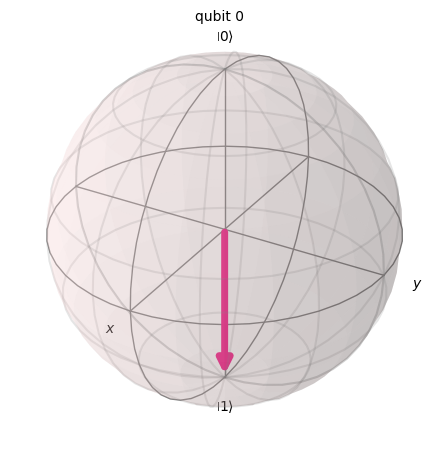

In [ ]:
backend = Aer.get_backend('statevector_simulator')
transpiled_qc_z = transpile(qc_z, backend)
result = backend.run(transpiled_qc_z).result().get_statevector(qc_z, decimals=3)

print("Result after implementing z-gate:\n",result)

plot_bloch_multivector(result)

***Unitary Gate***

In [ ]:
backend = Aer.get_backend('unitary_simulator')
result = backend.run(transpiled_qc_z).result().get_unitary(qc_z, decimals=3)
print("Unitary matrix after implementing z-gate:\n",result)

Unitary matrix after implementing z-gate:
 Operator([[ 0.+0.j,  1.+0.j],
          [-1.-0.j,  0.+0.j]],
         input_dims=(2,), output_dims=(2,))


***Measurement after Pauli-Z Gate***

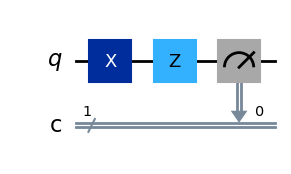

In [ ]:
# Measuring the qubit |0> after applying Y-gate

qc_z = QuantumCircuit(1,1,name='qc_y')
qc_z.x(0)
qc_z.z(0)

qc_z.measure(0,0)    # measure the qubit

qc_z.draw(output='mpl')


***Pauli-Z Gate on QASM simulator***

Counts after applying Y-gate and measuring the qubit: {'1': 1024}


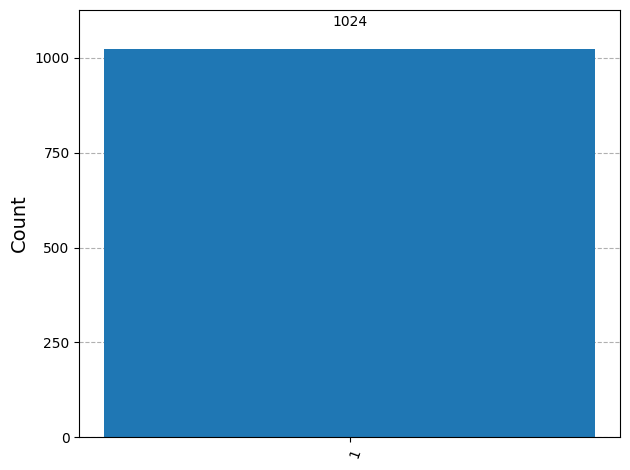

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_z, backend)

result = backend.run(job).result()
counts = result.get_counts(qc_z)

print("Counts after applying Y-gate and measuring the qubit:",counts)

plot_histogram(counts)

***Multiple Qubits***

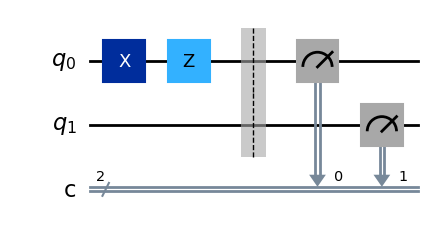

In [ ]:
qc_z = QuantumCircuit(2,2,name='qc_z')
# apply X-gate to the 0th qubit
qc_z.x(0)
# apply Z-gate to the 0th qubit
qc_z.z(0)
# applying barrier
qc_z.barrier()
# qc_z.measure(0,0)
# qc_z.measure(1,1)
# [0,1] is the list of qubits to be measured
# [0,1] is the list of clbits to store the result
qc_z.measure([0,1],[0,1])

qc_z.draw(output='mpl')


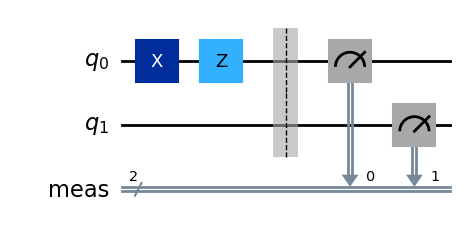

In [ ]:
qc_z = QuantumCircuit(2,name='qc_z')
# apply Z-gate to the 0th qubit
qc_z.x(0)
qc_z.z(0)

# measuring all qubits
qc_z.measure_all()

qc_z.draw(output='mpl')

---
***Hadamard Gate***

## 6. The Hadamard Gate

The **Hadamard gate** (H-gate) is one of the most important gates in quantum computing. It creates **superposition** by rotating the state vector 90° about the Y-axis followed by a 180° rotation about the X-axis. On the Bloch Sphere, this moves the qubit from the poles to the equator.

Its matrix form is:

$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

The Hadamard gate acts on the computational basis states as follows:

- $$ |0\rangle \rightarrow \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = |+\rangle $$
- $$ |1\rangle \rightarrow \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) = |-\rangle $$

These superposition states are essential for quantum parallelism and interference.



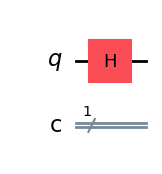

In [ ]:
# H-gate on |0> qubit
qc_h = QuantumCircuit(1,1,name='qc_h')

# apply H-gate to the 0th qubit
qc_h.h(0)
# qc.save_statevector()
# qc.save_unitary()
qc_h.draw(output='mpl')


### 6.1. Statevector Simulation

Let’s start with a qubit in the $$ |0\rangle $$ state and apply the Hadamard gate. This transforms it into the $$ |+\rangle $$ state, which is an equal superposition of $$ |0\rangle $$ and $$ |1\rangle $$.

The expected output statevector is:

$$
\frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 1 \end{pmatrix}
\quad \Rightarrow \quad [0.707+0.j,\ 0.707+0.j]
$$

This confirms that the qubit is in an equal superposition.

**Bloch Sphere visualization**:  
The qubit now lies along the X-axis (equator), indicating a pure $$ |+\rangle $$ state. Unlike the Z or Y gates, the Hadamard transforms the qubit into a probabilistic measurement state.

Result after implementing H-gate:
 Statevector([0.707+0.j, 0.707+0.j],
            dims=(2,))


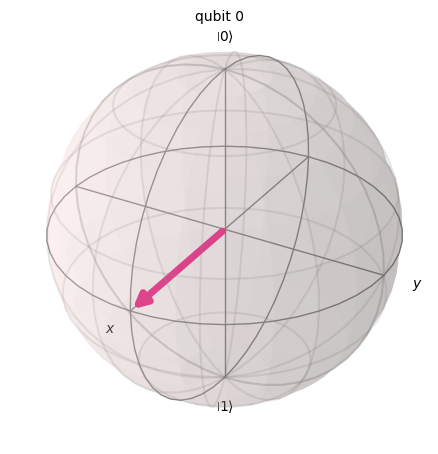

In [ ]:
backend = Aer.get_backend('statevector_simulator')
transpiled_qc_h = transpile(qc_h, backend)
result = backend.run(transpiled_qc_h).result().get_statevector(qc_h, decimals=3)

print("Result after implementing H-gate:\n",result)

plot_bloch_multivector(result)

***Unitary Operator***

In [ ]:
backend = Aer.get_backend('unitary_simulator')
result = backend.run(transpiled_qc_h).result().get_unitary(qc_h, decimals=3)
print("Unitary matrix after implementing H-gate:\n",result)

Unitary matrix after implementing H-gate:
 Operator([[ 0.707+0.j,  0.707-0.j],
          [ 0.707+0.j, -0.707+0.j]],
         input_dims=(2,), output_dims=(2,))


***Measurement after Hadamard Gate***


### 6.2. Measurement

When measuring the state:

$$
|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
$$

we get:

- $$ P(0) = \left| \frac{1}{\sqrt{2}} \right|^2 = \frac{1}{2} $$
- $$ P(1) = \left| \frac{1}{\sqrt{2}} \right|^2 = \frac{1}{2} $$

If we simulate this using the `qasm_simulator` with 1000 shots, we expect approximately 500 results of `0` and 500 results of `1`.

**Key Insight**:  
The Hadamard gate enables **quantum parallelism** by creating a coherent superposition of all possible classical states.



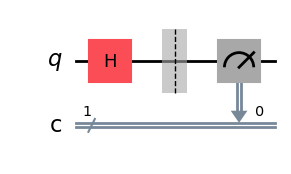

In [ ]:
# Measuring the qubit |0> after applying Y-gate

qc_h = QuantumCircuit(1,1,name='qc_y')
qc_h.h(0)
qc_h.barrier()
qc_h.measure(0,0)    # measure the qubit

qc_h.draw(output='mpl')


***Hadamard Gate on QASM simulator***

Counts after applying H-gate and measuring the qubit: {'0': 497, '1': 503}


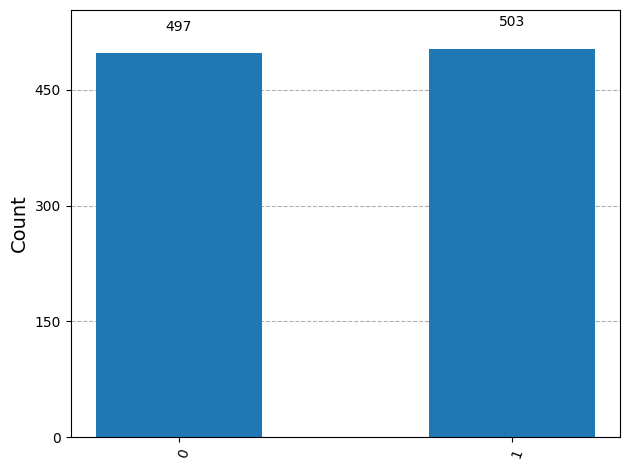

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_h, backend)

result = backend.run(job, shots=1000).result()
counts = result.get_counts(qc_h)

print("Counts after applying H-gate and measuring the qubit:",counts)

plot_histogram(counts)

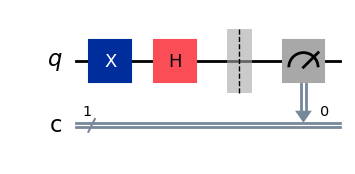

In [ ]:
# Measuring the qubit |0> after applying Y-gate

qc_h = QuantumCircuit(1,1,name='qc_y')
qc_h.x(0)
qc_h.h(0)
qc_h.barrier()
qc_h.measure(0,0)    # measure the qubit

qc_h.draw(output='mpl')


Counts after applying X-gate then H-gate and measuring the qubit: {'1': 492, '0': 508}


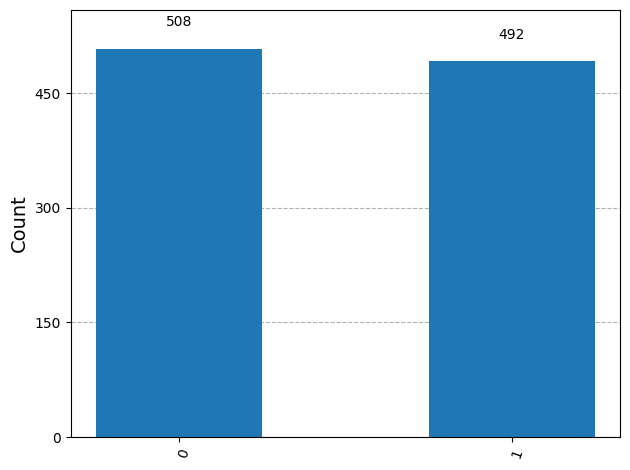

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_h, backend)

result = backend.run(job,shots = 1000).result()
counts = result.get_counts(qc_h)

print("Counts after applying X-gate then H-gate and measuring the qubit:",counts)

plot_histogram(counts)


***Multiple Qubits***

***2 Qubits***

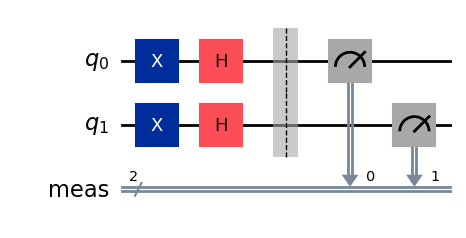

In [ ]:
qc_h = QuantumCircuit(2,name='qc_z')
# apply Z-gate to the 0th qubit
qc_h.x(0)
qc_h.h(0)
qc_h.x(1)
qc_h.h(1)
# measuring all qubits
qc_h.measure_all()

qc_h.draw(output='mpl')

Counts after applying X-gate then H-gate and measuring the qubit: {'11': 251, '01': 252, '00': 268, '10': 229}


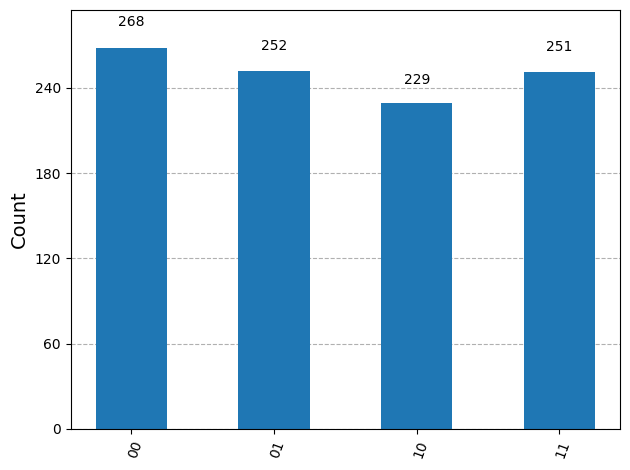

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_h, backend)

result = backend.run(job,shots = 1000).result()
counts = result.get_counts(qc_h)

print("Counts after applying X-gate then H-gate and measuring the qubit:",counts)

plot_histogram(counts)

Result after implementing H-gate:
 Statevector([1.+0.j, 0.+0.j, 0.-0.j, 0.+0.j],
            dims=(2, 2))


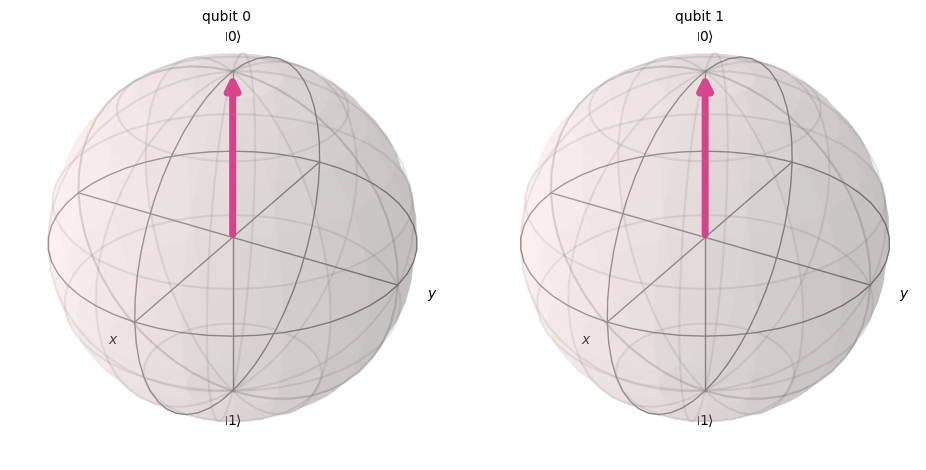

In [ ]:
backend = Aer.get_backend('statevector_simulator')
transpiled_qc_h = transpile(qc_h, backend)
result = backend.run(transpiled_qc_h).result().get_statevector(qc_h, decimals=3)

print("Result after implementing H-gate:\n",result)

plot_bloch_multivector(result)

***3 Qubits***

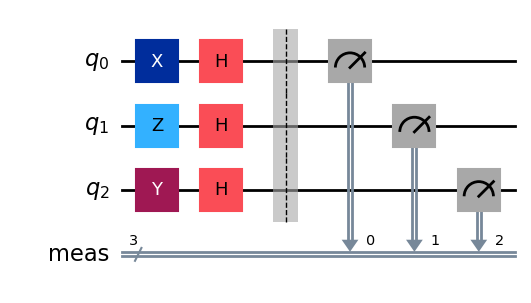

In [ ]:
qc_h = QuantumCircuit(3,name='qc_z')
# apply Z-gate to the 0th qubit
qc_h.x(0)
qc_h.h(0)
qc_h.z(1)
qc_h.h(1)
qc_h.y(2)
qc_h.h(2)
# measuring all qubits
qc_h.measure_all()

qc_h.draw(output='mpl')

Counts after applying X-gate then H-gate and measuring the qubit: {'101': 98, '100': 121, '110': 134, '000': 148, '010': 109, '111': 134, '011': 121, '001': 135}


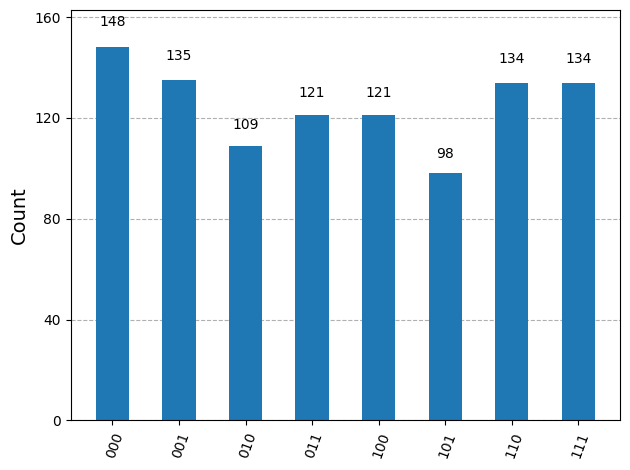

In [ ]:
backend = Aer.get_backend('qasm_simulator')
job = transpile(qc_h, backend)

result = backend.run(job,shots = 1000).result()
counts = result.get_counts(qc_h)

print("Counts after applying X-gate then H-gate and measuring the qubit:",counts)

plot_histogram(counts)

Result after implementing H-gate:
 Statevector([ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.+1.j,  0.+0.j,
             -0.+0.j],
            dims=(2, 2, 2))


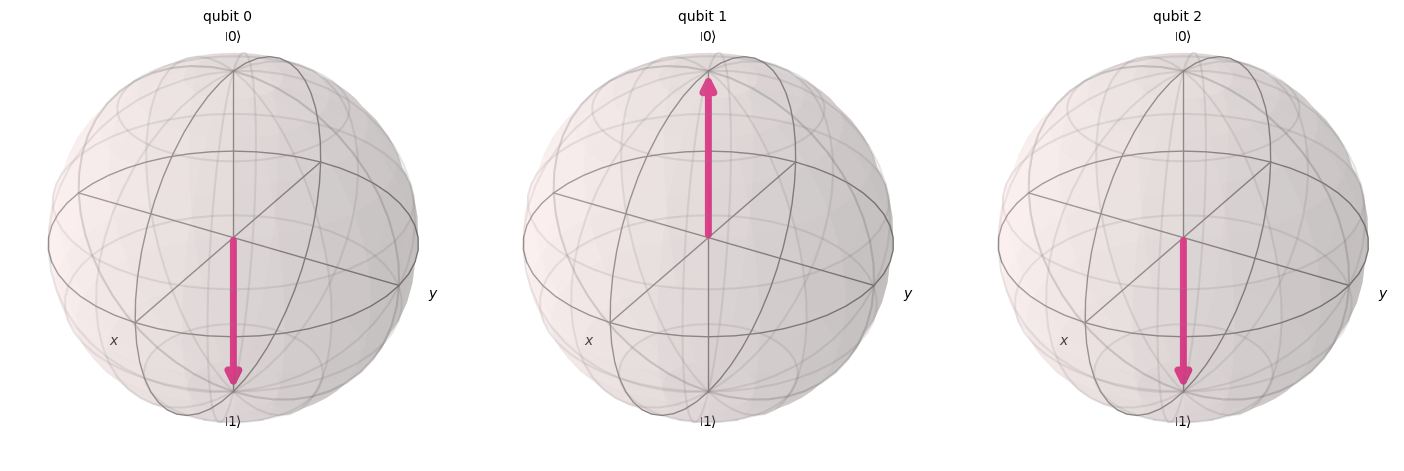

In [ ]:
backend = Aer.get_backend('statevector_simulator')
transpiled_qc_h = transpile(qc_h, backend)
result = backend.run(transpiled_qc_h).result().get_statevector(qc_h, decimals=3)

print("Result after implementing H-gate:\n",result)

plot_bloch_multivector(result)